### Llamada de paquetes y base de datos

In [1]:
# --- Librerías estándar ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Visualización ---
import seaborn as sns
from matplotlib import rcParams
from matplotlib.colors import ListedColormap

# --- Statsmodels ---
import statsmodels.api as sm
from scipy.stats import ttest_ind

# --- Scikit-learn ---
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, precision_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

import re
from sklearn.tree import export_graphviz
import graphviz

In [2]:
EPH = pd.read_csv("EPH_merged.csv", low_memory=False)

In [3]:
# Transformación logarítmica
EPH['log_horastrab'] = np.log1p(EPH['horastrab'])

# Imputación de variables
EPH['educ'] = pd.to_numeric(EPH['educ'], errors='coerce')
EPH['educ'] = EPH['educ'].fillna(EPH['educ'].mean())
EPH['CH06'] = pd.to_numeric(EPH['CH06'], errors='coerce')
EPH['CH06'] = EPH['CH06'].fillna(EPH['CH06'].median())
EPH['IX_TOT'] = pd.to_numeric(EPH['IX_TOT'], errors='coerce')
EPH['IX_TOT'] = EPH['IX_TOT'].fillna(EPH['IX_TOT'].median())
EPH['horastrab'] = EPH['horastrab'].fillna(0)

# Variables dummies
EPH['mujer'] = (EPH['CH04'] == 2).astype(int)
EPH['en_pareja'] = EPH['CH07'].isin([1, 2]).astype(int)
EPH['sin_cobertura'] = EPH['CH08'].isin([4, 9]).astype(int)
EPH['solo_publica'] = EPH['CH08'].isin([3, 13, 23]).astype(int)
EPH['con_obra_social_o_prepaga'] = EPH['CH08'].isin([1, 2, 12, 123]).astype(int)
EPH['ocupado'] = (EPH['ESTADO'] == 1).astype(int)
EPH['inactivo_no_jubilado'] = EPH['CAT_INAC'].isin([3,4,5,6,7]).astype(int)
EPH['trabajo_no_rem'] = (EPH['CAT_OCUP'] == 4).astype(int)
EPH['cuenta_propia_o_patron'] = EPH['CAT_OCUP'].isin([1,2]).astype(int)

# Lista de variables dummy (CORREGIDA)
dummy_vars = [
    'mujer', 'en_pareja', 'ocupado',
    'solo_publica', 'con_obra_social_o_prepaga',
    'trabajo_no_rem', 'cuenta_propia_o_patron', 'inactivo_no_jubilado'
]

for c in dummy_vars:
    EPH[c] = EPH[c].fillna(0)

# Separación de datos
respondieron = EPH[EPH['ITF'] > 0].copy()
respondieron_2025 = respondieron[respondieron['ANIO'] == 2025].copy()

# Variables predictoras y objetivo
X_vars = ['CH06', 'educ', 'IX_TOT', 'log_horastrab'] + dummy_vars
X_vars = list(dict.fromkeys(X_vars))
y_var = 'pobre'

In [4]:
# PREPARACIÓN PARA REGRESIÓN LOGÍSTICA

# Crear X e y
X = respondieron_2025[X_vars].copy()
y = respondieron_2025[y_var].copy()

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=444
)

# Estandarización 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_vars)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_vars)

print(f"Dimensiones: X_train={X_train_scaled.shape}, X_test={X_test_scaled.shape}")
print(f"Proporción de pobres en train: {y_train.mean():.2%}")
print(f"Proporción de pobres en test: {y_test.mean():.2%}")

Dimensiones: X_train=(6055, 12), X_test=(2596, 12)
Proporción de pobres en train: 45.10%
Proporción de pobres en test: 43.84%


# PUNTO A: Modelo de Regresión Logística con Regularización: Ridge y LASSO 

## Ejercicio 1

In [5]:
# GRILLA DE PARÁMETROS DE PENALIDAD


# C es la INVERSA de la penalidad, entonces C = 1/lambda
# lambda = 10^n con n ∈ {-5, -4, -3, ..., 4, 5}
n_values = np.arange(-5, 6)  # -5 a 5
lambda_values = 10.0 ** n_values
C_values = 1.0 / lambda_values  # C es la inversa

print(f"\nGrilla de penalidades:")
print(f"n: {n_values}")
print(f"λ (lambda): {lambda_values}")
print(f"C (para sklearn): {C_values}")



Grilla de penalidades:
n: [-5 -4 -3 -2 -1  0  1  2  3  4  5]
λ (lambda): [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04
 1.e+05]
C (para sklearn): [1.e+05 1.e+04 1.e+03 1.e+02 1.e+01 1.e+00 1.e-01 1.e-02 1.e-03 1.e-04
 1.e-05]


### RIDGE (L2) - Entrenamiento

In [6]:
ridge_coefs = []
ridge_intercepts = []

for C in C_values:
    model = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',  
        max_iter=1000,
        random_state=444
    )
    model.fit(X_train_scaled, y_train)
    ridge_coefs.append(model.coef_[0])
    ridge_intercepts.append(model.intercept_[0])

ridge_coefs_df = pd.DataFrame(ridge_coefs, columns=X_vars)
ridge_coefs_df['lambda'] = lambda_values
ridge_coefs_df['C'] = C_values

### LASSO (L1) - Entrenamiento

In [7]:
lasso_coefs = []
lasso_intercepts = []

for C in C_values:
    model = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',  # Necesario para L1
        max_iter=1000,
        random_state=444
    )
    model.fit(X_train_scaled, y_train)
    lasso_coefs.append(model.coef_[0])
    lasso_intercepts.append(model.intercept_[0])

lasso_coefs_df = pd.DataFrame(lasso_coefs, columns=X_vars)
lasso_coefs_df['lambda'] = lambda_values
lasso_coefs_df['C'] = C_values


### Visualización

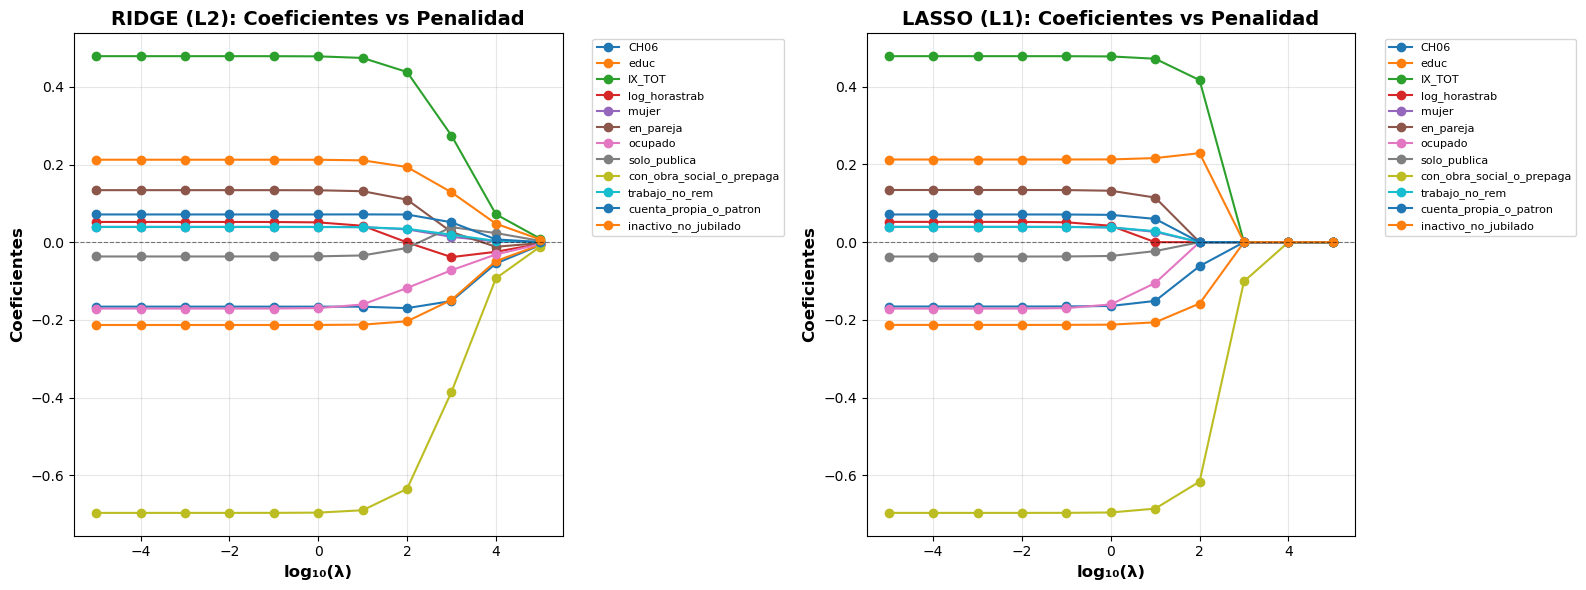

In [8]:
# ============================================
# 6. VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Ridge (L2)
ax1 = axes[0]
for col in X_vars:
    ax1.plot(np.log10(ridge_coefs_df['lambda']), 
             ridge_coefs_df[col], 
             marker='o', 
             label=col)

ax1.set_xlabel('log₁₀(λ)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coeficientes', fontsize=12, fontweight='bold')
ax1.set_title('RIDGE (L2): Coeficientes vs Penalidad', fontsize=14, fontweight='bold')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Panel 2: LASSO (L1)
ax2 = axes[1]
for col in X_vars:
    ax2.plot(np.log10(lasso_coefs_df['lambda']), 
             lasso_coefs_df[col], 
             marker='o', 
             label=col)

ax2.set_xlabel('log₁₀(λ)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coeficientes', fontsize=12, fontweight='bold')
ax2.set_title('LASSO (L1): Coeficientes vs Penalidad', fontsize=14, fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# 7. ANÁLISIS DE RESULTADOS
# ============================================

print("\n" + "="*70)
print("ANÁLISIS DE COEFICIENTES CON DIFERENTES PENALIDADES")
print("="*70)

# Ridge: λ mínimo y máximo
print("\n--- RIDGE (L2) ---")
print(f"\nλ mínimo (10^-5 = {lambda_values[0]}):")
print(ridge_coefs_df.iloc[0][X_vars].round(4))
print(f"\nλ máximo (10^5 = {lambda_values[-1]}):")
print(ridge_coefs_df.iloc[-1][X_vars].round(4))

# LASSO: λ mínimo y máximo
print("\n--- LASSO (L1) ---")
print(f"\nλ mínimo (10^-5 = {lambda_values[0]}):")
print(lasso_coefs_df.iloc[0][X_vars].round(4))
print(f"\nλ máximo (10^5 = {lambda_values[-1]}):")
print(lasso_coefs_df.iloc[-1][X_vars].round(4))

# Conteo de coeficientes en cero con LASSO
print("\n--- SELECCIÓN DE VARIABLES CON LASSO ---")
print("\nNúmero de coeficientes = 0 para cada λ:")
for i, lam in enumerate(lambda_values):
    n_zeros = (np.abs(lasso_coefs_df.iloc[i][X_vars]) < 1e-10).sum()
    print(f"λ = 10^{n_values[i]} ({lam:.0e}): {n_zeros} variables eliminadas")


ANÁLISIS DE COEFICIENTES CON DIFERENTES PENALIDADES

--- RIDGE (L2) ---

λ mínimo (10^-5 = 1e-05):
CH06                        -0.1659
educ                        -0.2131
IX_TOT                       0.4789
log_horastrab                0.0521
mujer                        0.0396
en_pareja                    0.1340
ocupado                     -0.1708
solo_publica                -0.0367
con_obra_social_o_prepaga   -0.6968
trabajo_no_rem               0.0391
cuenta_propia_o_patron       0.0714
inactivo_no_jubilado         0.2123
Name: 0, dtype: float64

λ máximo (10^5 = 100000.0):
CH06                        -0.0075
educ                        -0.0066
IX_TOT                       0.0090
log_horastrab               -0.0041
mujer                        0.0002
en_pareja                   -0.0024
ocupado                     -0.0049
solo_publica                 0.0034
con_obra_social_o_prepaga   -0.0112
trabajo_no_rem               0.0003
cuenta_propia_o_patron       0.0003
inactivo_no_jubilad

## Ejercicio 2

### CROSS-VALIDATION

In [10]:
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled_array = X_train_scaled.values
else:
    X_train_scaled_array = X_train_scaled

y_train_array = y_train.values

# Grilla de penalidades
n_values = np.arange(-5, 6)
lambda_values = 10.0 ** n_values
C_values = 1.0 / lambda_values

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=444)

In [11]:
ridge_cv_errors = []
ridge_cv_means = []
ridge_cv_stds = []

print("\n--- RIDGE (L2) ---")
for i, C in enumerate(C_values):
    fold_errors = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled_array)):
        X_tr = X_train_scaled_array[train_idx]
        X_val = X_train_scaled_array[val_idx]
        y_tr = y_train_array[train_idx]
        y_val = y_train_array[val_idx]
        
        model = LogisticRegression(
            penalty='l2',
            C=C,
            solver='lbfgs',
            max_iter=1000,
            random_state=444
        )
        model.fit(X_tr, y_tr)
        
        # Error de clasificación = 1 - accuracy
        y_pred = model.predict(X_val)
        error = 1 - accuracy_score(y_val, y_pred)
        fold_errors.append(error)
    
    ridge_cv_errors.append(fold_errors)
    ridge_cv_means.append(np.mean(fold_errors))
    ridge_cv_stds.append(np.std(fold_errors))
    
    print(f"λ = 10^{n_values[i]:2d} ({lambda_values[i]:.0e}) | "
          f"Error CV: {ridge_cv_means[-1]:.4f} ± {ridge_cv_stds[-1]:.4f}")

# Encontrar λ óptimo para Ridge
ridge_best_idx = np.argmin(ridge_cv_means)
ridge_best_lambda = lambda_values[ridge_best_idx]
ridge_best_C = C_values[ridge_best_idx]
ridge_best_error = ridge_cv_means[ridge_best_idx]

print(f"\n RIDGE - λ óptimo: {ridge_best_lambda:.0e} (10^{n_values[ridge_best_idx]})")
print(f"   Error CV: {ridge_best_error:.4f}")


--- RIDGE (L2) ---
λ = 10^-5 (1e-05) | Error CV: 0.2844 ± 0.0146
λ = 10^-4 (1e-04) | Error CV: 0.2844 ± 0.0146
λ = 10^-3 (1e-03) | Error CV: 0.2844 ± 0.0146
λ = 10^-2 (1e-02) | Error CV: 0.2844 ± 0.0146
λ = 10^-1 (1e-01) | Error CV: 0.2844 ± 0.0146
λ = 10^ 0 (1e+00) | Error CV: 0.2842 ± 0.0148
λ = 10^ 1 (1e+01) | Error CV: 0.2844 ± 0.0154
λ = 10^ 2 (1e+02) | Error CV: 0.2865 ± 0.0147
λ = 10^ 3 (1e+03) | Error CV: 0.2991 ± 0.0114
λ = 10^ 4 (1e+04) | Error CV: 0.3528 ± 0.0200
λ = 10^ 5 (1e+05) | Error CV: 0.4510 ± 0.0122

 RIDGE - λ óptimo: 1e+00 (10^0)
   Error CV: 0.2842


In [12]:
lasso_cv_errors = []
lasso_cv_means = []
lasso_cv_stds = []
lasso_prop_zeros = []

print("\n--- LASSO (L1) ---")
for i, C in enumerate(C_values):
    fold_errors = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled_array)):
        X_tr = X_train_scaled_array[train_idx]
        X_val = X_train_scaled_array[val_idx]
        y_tr = y_train_array[train_idx]
        y_val = y_train_array[val_idx]
        
        model = LogisticRegression(
            penalty='l1',
            C=C,
            solver='liblinear',
            max_iter=1000,
            random_state=444
        )
        model.fit(X_tr, y_tr)
        
        y_pred = model.predict(X_val)
        error = 1 - accuracy_score(y_val, y_pred)
        fold_errors.append(error)
    
    lasso_cv_errors.append(fold_errors)
    lasso_cv_means.append(np.mean(fold_errors))
    lasso_cv_stds.append(np.std(fold_errors))
    
    # Calcular proporción de variables eliminadas (usando último fold)
    n_zeros = (np.abs(model.coef_[0]) < 1e-10).sum()
    prop_zeros = n_zeros / len(X_vars)
    lasso_prop_zeros.append(prop_zeros)
    
    print(f"λ = 10^{n_values[i]:2d} ({lambda_values[i]:.0e}) | "
          f"Error CV: {lasso_cv_means[-1]:.4f} ± {lasso_cv_stds[-1]:.4f} | "
          f"Variables eliminadas: {n_zeros}/{len(X_vars)} ({prop_zeros:.1%})")

# Encontrar λ óptimo para LASSO
lasso_best_idx = np.argmin(lasso_cv_means)
lasso_best_lambda = lambda_values[lasso_best_idx]
lasso_best_C = C_values[lasso_best_idx]
lasso_best_error = lasso_cv_means[lasso_best_idx]

print(f"\n LASSO - λ óptimo: {lasso_best_lambda:.0e} (10^{n_values[lasso_best_idx]})")
print(f"   Error CV: {lasso_best_error:.4f}")


--- LASSO (L1) ---
λ = 10^-5 (1e-05) | Error CV: 0.2842 ± 0.0146 | Variables eliminadas: 0/12 (0.0%)
λ = 10^-4 (1e-04) | Error CV: 0.2842 ± 0.0146 | Variables eliminadas: 0/12 (0.0%)
λ = 10^-3 (1e-03) | Error CV: 0.2842 ± 0.0146 | Variables eliminadas: 0/12 (0.0%)
λ = 10^-2 (1e-02) | Error CV: 0.2842 ± 0.0146 | Variables eliminadas: 0/12 (0.0%)
λ = 10^-1 (1e-01) | Error CV: 0.2842 ± 0.0148 | Variables eliminadas: 0/12 (0.0%)
λ = 10^ 0 (1e+00) | Error CV: 0.2836 ± 0.0152 | Variables eliminadas: 0/12 (0.0%)
λ = 10^ 1 (1e+01) | Error CV: 0.2857 ± 0.0162 | Variables eliminadas: 1/12 (8.3%)
λ = 10^ 2 (1e+02) | Error CV: 0.2872 ± 0.0181 | Variables eliminadas: 7/12 (58.3%)
λ = 10^ 3 (1e+03) | Error CV: 0.4510 ± 0.0122 | Variables eliminadas: 12/12 (100.0%)
λ = 10^ 4 (1e+04) | Error CV: 0.4510 ± 0.0122 | Variables eliminadas: 12/12 (100.0%)
λ = 10^ 5 (1e+05) | Error CV: 0.4510 ± 0.0122 | Variables eliminadas: 12/12 (100.0%)

 LASSO - λ óptimo: 1e+00 (10^0)
   Error CV: 0.2836


### Box-plots

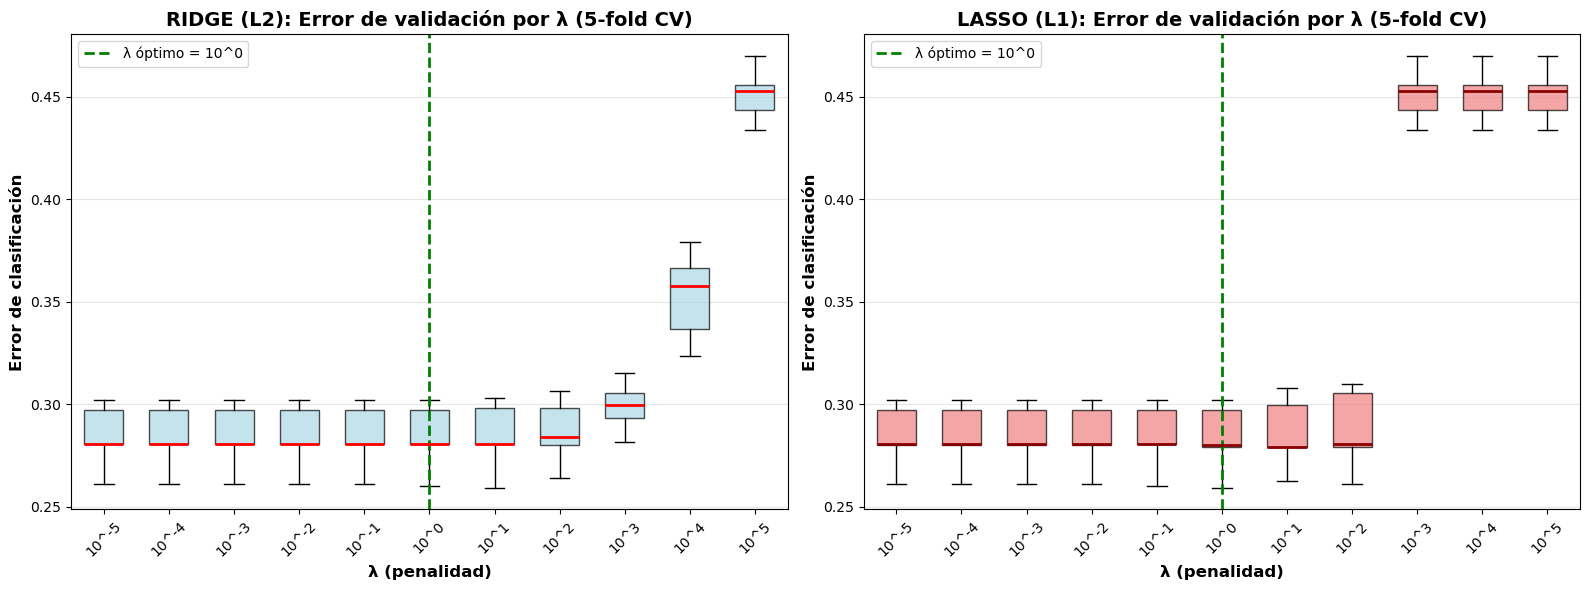

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box-plot RIDGE
ax1 = axes[0]
bp1 = ax1.boxplot(ridge_cv_errors, 
                   positions=range(len(lambda_values)),
                   widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))

ax1.set_xlabel('λ (penalidad)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Error de clasificación', fontsize=12, fontweight='bold')
ax1.set_title('RIDGE (L2): Error de validación por λ (5-fold CV)', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(lambda_values)))
ax1.set_xticklabels([f'10^{n}' for n in n_values], rotation=45)
ax1.axvline(x=ridge_best_idx, color='green', linestyle='--', 
            linewidth=2, label=f'λ óptimo = 10^{n_values[ridge_best_idx]}')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# Box-plot LASSO
ax2 = axes[1]
bp2 = ax2.boxplot(lasso_cv_errors,
                   positions=range(len(lambda_values)),
                   widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', alpha=0.7),
                   medianprops=dict(color='darkred', linewidth=2))

ax2.set_xlabel('λ (penalidad)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Error de clasificación', fontsize=12, fontweight='bold')
ax2.set_title('LASSO (L1): Error de validación por λ (5-fold CV)', 
              fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(lambda_values)))
ax2.set_xticklabels([f'10^{n}' for n in n_values], rotation=45)
ax2.axvline(x=lasso_best_idx, color='green', linestyle='--', 
            linewidth=2, label=f'λ óptimo = 10^{n_values[lasso_best_idx]}')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.show()

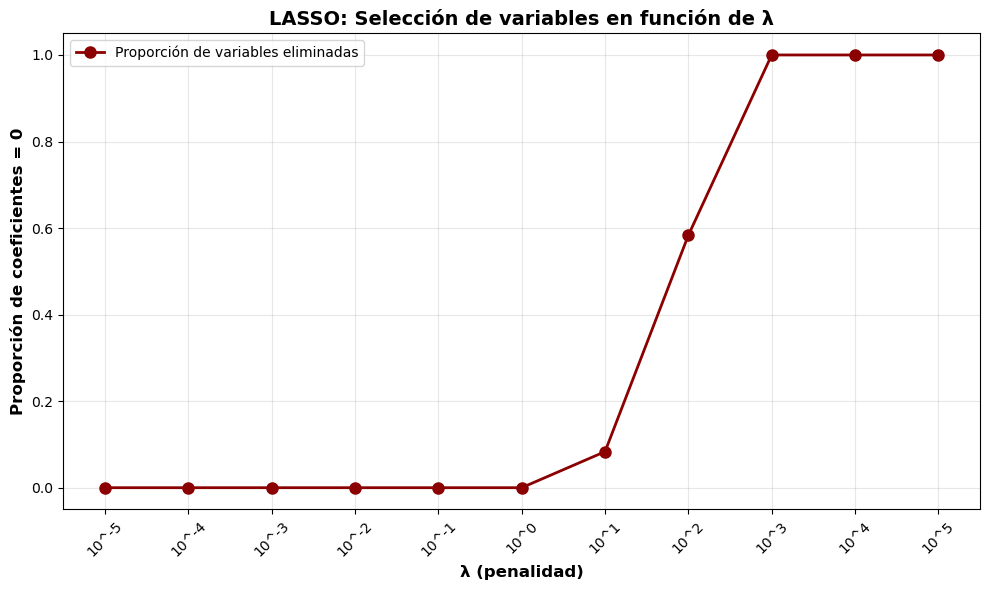

In [14]:
# Proporción de variables eliminadas (LASSO)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(lambda_values)), 
        lasso_prop_zeros, 
        marker='o', 
        markersize=8,
        linewidth=2,
        color='darkred',
        label='Proporción de variables eliminadas')

ax.set_xlabel('λ (penalidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('Proporción de coeficientes = 0', fontsize=12, fontweight='bold')
ax.set_title('LASSO: Selección de variables en función de λ', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(len(lambda_values)))
ax.set_xticklabels([f'10^{n}' for n in n_values], rotation=45)
ax1.axvline(x=lasso_best_idx, color='green', linestyle='--', 
           linewidth=2, label=f'λ óptimo = 10^{n_values[lasso_best_idx]}')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [15]:
# GUARDAR RESULTADOS PARA EL PUNTO 3

print("RESULTADOS PARA USAR EN EL PUNTO 3")
print(f"\nRIDGE:")
print(f"  - λ óptimo: {ridge_best_lambda:.0e}")
print(f"  - C óptimo (para sklearn): {ridge_best_C:.0e}")
print(f"  - Error CV: {ridge_best_error:.4f}")

print(f"\nLASSO:")
print(f"  - λ óptimo: {lasso_best_lambda:.0e}")
print(f"  - C óptimo (para sklearn): {lasso_best_C:.0e}")
print(f"  - Error CV: {lasso_best_error:.4f}")
print(f"  - Variables eliminadas con λ óptimo: {int(lasso_prop_zeros[lasso_best_idx] * len(X_vars))}/{len(X_vars)}")

# Guardar en variables para el siguiente punto
print(f"ridge_best_C = {ridge_best_C}")
print(f"lasso_best_C = {lasso_best_C}")

RESULTADOS PARA USAR EN EL PUNTO 3

RIDGE:
  - λ óptimo: 1e+00
  - C óptimo (para sklearn): 1e+00
  - Error CV: 0.2842

LASSO:
  - λ óptimo: 1e+00
  - C óptimo (para sklearn): 1e+00
  - Error CV: 0.2836
  - Variables eliminadas con λ óptimo: 0/12
ridge_best_C = 1.0
lasso_best_C = 1.0


## Ejercicio 3

In [16]:
# COMPARACIÓN DE MODELOS

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Usar los λ óptimos
ridge_best_C = 1.0  # λ = 1.0
lasso_best_C = 1.0  # λ = 1.0

# Asegurarnos de tener X_train_scaled como array
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled_array = X_train_scaled.values
else:
    X_train_scaled_array = X_train_scaled

y_train_array = y_train.values

### Sin penalidad

In [17]:
# MODELO 1: SIN PENALIDAD

model_no_penalty = LogisticRegression(
    penalty=None,  # Sin penalidad
    solver='lbfgs',
    max_iter=1000,
    random_state=444
)
model_no_penalty.fit(X_train_scaled_array, y_train_array)

coef_no_penalty = model_no_penalty.coef_[0]
intercept_no_penalty = model_no_penalty.intercept_[0]

print(f"   Intercepto: {intercept_no_penalty:.4f}")
print(f"   Número de coeficientes != 0: {(np.abs(coef_no_penalty) > 1e-10).sum()}/{len(X_vars)}")

   Intercepto: -0.2306
   Número de coeficientes != 0: 12/12


### RIDGE

In [18]:
# MODELO 2: RIDGE (L2) CON λ ÓPTIMO

model_ridge = LogisticRegression(
    penalty='l2',
    C=ridge_best_C,
    solver='lbfgs',
    max_iter=1000,
    random_state=444
)
model_ridge.fit(X_train_scaled_array, y_train_array)

coef_ridge = model_ridge.coef_[0]
intercept_ridge = model_ridge.intercept_[0]

print(f"   Intercepto: {intercept_ridge:.4f}")
print(f"   Número de coeficientes != 0: {(np.abs(coef_ridge) > 1e-10).sum()}/{len(X_vars)}")

   Intercepto: -0.2306
   Número de coeficientes != 0: 12/12


### LASSO

In [19]:
# MODELO 3: LASSO (L1) CON λ ÓPTIMO

model_lasso = LogisticRegression(
    penalty='l1',
    C=lasso_best_C,
    solver='liblinear',
    max_iter=1000,
    random_state=444
)
model_lasso.fit(X_train_scaled_array, y_train_array)

coef_lasso = model_lasso.coef_[0]
intercept_lasso = model_lasso.intercept_[0]

print(f"   Intercepto: {intercept_lasso:.4f}")
print(f"   Número de coeficientes != 0: {(np.abs(coef_lasso) > 1e-10).sum()}/{len(X_vars)}")

   Intercepto: -0.2295
   Número de coeficientes != 0: 12/12


### Tabla de valores

In [20]:
# TABLA COMPARATIVA

tabla_comparacion = pd.DataFrame({
    'Variable': X_vars,
    'Sin_Penalidad': coef_no_penalty,
    'Ridge_L2': coef_ridge,
    'LASSO_L1': coef_lasso
})

# Agregar columnas de diferencias
tabla_comparacion['Diff_Ridge'] = tabla_comparacion['Ridge_L2'] - tabla_comparacion['Sin_Penalidad']
tabla_comparacion['Diff_LASSO'] = tabla_comparacion['LASSO_L1'] - tabla_comparacion['Sin_Penalidad']
tabla_comparacion['LASSO_Eliminada'] = (np.abs(tabla_comparacion['LASSO_L1']) < 1e-10).astype(int)

# Ordenar por magnitud del coeficiente sin penalidad
tabla_comparacion['Abs_Sin_Penalidad'] = np.abs(tabla_comparacion['Sin_Penalidad'])
tabla_comparacion = tabla_comparacion.sort_values('Abs_Sin_Penalidad', ascending=False)
tabla_comparacion = tabla_comparacion.drop('Abs_Sin_Penalidad', axis=1)

print("\n" + "="*70)
print("TABLA COMPARATIVA DE COEFICIENTES")
print("="*70)
print(tabla_comparacion.to_string(index=False))

# Exportar a CSV
tabla_comparacion.to_csv('comparacion_coeficientes.csv', index=False)


TABLA COMPARATIVA DE COEFICIENTES
                 Variable  Sin_Penalidad  Ridge_L2  LASSO_L1  Diff_Ridge  Diff_LASSO  LASSO_Eliminada
con_obra_social_o_prepaga      -0.696799 -0.696092 -0.695592    0.000707    0.001207                0
                   IX_TOT       0.478872  0.478399  0.478053   -0.000473   -0.000819                0
                     educ      -0.213128 -0.213036 -0.212250    0.000092    0.000877                0
     inactivo_no_jubilado       0.212332  0.212191  0.212996   -0.000141    0.000664                0
                  ocupado      -0.170806 -0.169671 -0.160185    0.001135    0.010621                0
                     CH06      -0.165896 -0.165925 -0.164165   -0.000029    0.001731                0
                en_pareja       0.133971  0.133686  0.132413   -0.000286   -0.001559                0
   cuenta_propia_o_patron       0.071410  0.071416  0.070357    0.000006   -0.001053                0
            log_horastrab       0.052117  0.051

# PUNTO B: Árboles

## Ejercicio 4

In [23]:
print("Tipo de X_train:", type(X_train))
print("Tipo de y_train:", type(y_train))
print("Valores faltantes en X_train:", X_train.isnull().sum().sum() if hasattr(X_train, 'isnull') else np.isnan(X_train).sum())
print("Valores faltantes en y_train:", y_train.isnull().sum() if hasattr(y_train, 'isnull') else np.isnan(y_train).sum())
print("Forma X_train:", X_train.shape)
print("Forma y_train:", y_train.shape)

Tipo de X_train: <class 'pandas.core.frame.DataFrame'>
Tipo de y_train: <class 'pandas.core.series.Series'>
Valores faltantes en X_train: 0
Valores faltantes en y_train: 0
Forma X_train: (6055, 12)
Forma y_train: (6055,)


In [24]:
# VERIFICACIÓN

print("="*70)
print("PUNTO 4 Y 5: ÁRBOLES DE DECISIÓN (CART)")
print("="*70)

# Verificar dimensiones
print(f"\nDimensiones de los datos:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

PUNTO 4 Y 5: ÁRBOLES DE DECISIÓN (CART)

Dimensiones de los datos:
  X_train: (6055, 12)
  X_test: (2596, 12)
  y_train: (6055,)
  y_test: (2596,)


### CROSS-VALIDATION para CART

In [25]:
# CROSS-VALIDATION PARA ccp_alpha

tree_full = DecisionTreeClassifier(random_state=444)
tree_full.fit(X_train, y_train)

# Obtener el camino de poda
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"   Número de valores de ccp_alpha disponibles: {len(ccp_alphas)}")
print(f"   Rango: {ccp_alphas.min():.6f} a {ccp_alphas.max():.6f}")

ccp_alphas = np.maximum(ccp_alphas, 0)  # Asegurar que todos sean >= 0

# Seleccionar grilla de ccp_alpha usando percentiles
percentiles = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 85, 90, 95, 100]
ccp_alpha_grid = np.percentile(ccp_alphas, percentiles)
ccp_alpha_grid = np.unique(ccp_alpha_grid)  # Eliminar duplicados
ccp_alpha_grid = np.maximum(ccp_alpha_grid, 0)  # Asegurar >= 0

print(f"\n2. Grilla de ccp_alpha seleccionada ({len(ccp_alpha_grid)} valores):")
for i, alpha in enumerate(ccp_alpha_grid):
    print(f"   [{i}] {alpha:.6f}")

# Cross-Validation con 10 folds
print("\n3. Ejecutando 10-Fold Cross-Validation...")

cv_scores_mean = []
cv_scores_std = []

for i, alpha in enumerate(ccp_alpha_grid):
    print(f"   Probando ccp_alpha [{i}/{len(ccp_alpha_grid)-1}]: {alpha:.6f}...", end=' ')
    
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=444)
    
    try:
        scores = cross_val_score(tree, X_train, y_train, cv=10, 
                                scoring='accuracy', error_score='raise')
        
        # Error de clasificación = 1 - accuracy
        errors = 1 - scores
        
        cv_scores_mean.append(errors.mean())
        cv_scores_std.append(errors.std())
        print(f"Error: {errors.mean():.4f}")
        
    except Exception as e:
        print(f"ERROR: {str(e)[:100]}")
        cv_scores_mean.append(np.nan)
        cv_scores_std.append(np.nan)

cv_scores_mean = np.array(cv_scores_mean)
cv_scores_std = np.array(cv_scores_std)

# Filtrar valores válidos
valid_mask = ~np.isnan(cv_scores_mean)
if not valid_mask.any():
    raise ValueError("No se pudieron calcular scores de CV válidos.")


# Encontrar el mejor ccp_alpha (solo entre valores válidos)
best_idx = np.argmin(cv_scores_mean[valid_mask])
best_idx = np.where(valid_mask)[0][best_idx]  # Índice en la grilla original
best_ccp_alpha = ccp_alpha_grid[best_idx]
best_error = cv_scores_mean[best_idx]

print(f"\nRESULTADO:")
print(f"   ccp_alpha óptimo: {best_ccp_alpha:.6f}")
print(f"   Error CV: {best_error:.4f} ± {cv_scores_std[best_idx]:.4f}")

   Número de valores de ccp_alpha disponibles: 799
   Rango: -0.000000 a 0.072467

2. Grilla de ccp_alpha seleccionada (14 valores):
   [0] 0.000000
   [1] 0.000017
   [2] 0.000035
   [3] 0.000066
   [4] 0.000096
   [5] 0.000111
   [6] 0.000138
   [7] 0.000156
   [8] 0.000189
   [9] 0.000223
   [10] 0.000253
   [11] 0.000297
   [12] 0.000384
   [13] 0.072467

3. Ejecutando 10-Fold Cross-Validation...
Error: 0.3704cp_alpha [0/13]: 0.000000... 
Error: 0.3698cp_alpha [1/13]: 0.000017... 
Error: 0.3706cp_alpha [2/13]: 0.000035... 
Error: 0.3701cp_alpha [3/13]: 0.000066... 
Error: 0.3650cp_alpha [4/13]: 0.000096... 
Error: 0.3642cp_alpha [5/13]: 0.000111... 
Error: 0.3552cp_alpha [6/13]: 0.000138... 
Error: 0.3478cp_alpha [7/13]: 0.000156... 
Error: 0.3316cp_alpha [8/13]: 0.000189... 
Error: 0.3247cp_alpha [9/13]: 0.000223... 
Error: 0.3128cp_alpha [10/13]: 0.000253... 
Error: 0.3088cp_alpha [11/13]: 0.000297... 
Error: 0.2945cp_alpha [12/13]: 0.000384... 
Error: 0.3871cp_alpha [13/13]: 0.0

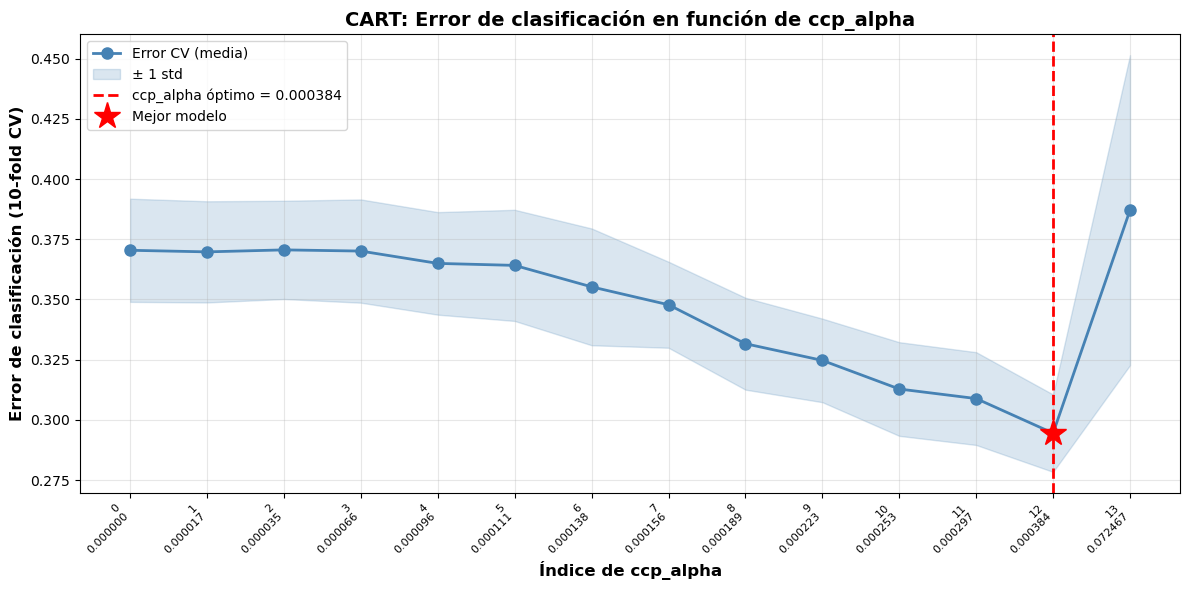

In [39]:
# VISUALIZACIÓN: ERROR vs ccp_alpha

fig, ax = plt.subplots(figsize=(12, 6))

# Solo graficar valores válidos
valid_indices = np.where(valid_mask)[0]
ax.plot(valid_indices, cv_scores_mean[valid_mask], 
        marker='o', linewidth=2, markersize=8, color='steelblue', label='Error CV (media)')
ax.fill_between(valid_indices, 
                cv_scores_mean[valid_mask] - cv_scores_std[valid_mask],
                cv_scores_mean[valid_mask] + cv_scores_std[valid_mask],
                alpha=0.2, color='steelblue', label='± 1 std')

# Marcar el mejor valor
ax.axvline(x=best_idx, color='red', linestyle='--', linewidth=2, 
          label=f'ccp_alpha óptimo = {best_ccp_alpha:.6f}')
ax.plot(best_idx, best_error, 'r*', markersize=20, label='Mejor modelo')

ax.set_xlabel('Índice de ccp_alpha', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Error de clasificación (10-fold CV)', fontsize=12, fontweight='bold')
ax.set_title('CART: Error de clasificación en función de ccp_alpha', 
            fontsize=14, fontweight='bold')
ax.set_xticks(range(len(ccp_alpha_grid)))
ax.set_xticklabels([f'{i}\n{ccp_alpha_grid[i]:.6f}' for i in range(len(ccp_alpha_grid))], 
                   rotation=45, ha='right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.savefig('cart_ccp_alpha_cv.png', dpi=300, bbox_inches='tight')
plt.show()

## Ejercicio 5

In [27]:
#ENTRENAR ÁRBOL ÓPTIMO Y VISUALIZAR

tree_optimal = DecisionTreeClassifier(ccp_alpha=best_ccp_alpha, random_state=444)
tree_optimal.fit(X_train, y_train)

# Métricas del árbol óptimo
y_train_pred = tree_optimal.predict(X_train)
y_test_pred = tree_optimal.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n MÉTRICAS DEL ÁRBOL ÓPTIMO:")
print(f"   Profundidad: {tree_optimal.get_depth()}")
print(f"   Número de hojas: {tree_optimal.get_n_leaves()}")
print(f"   Número de nodos: {tree_optimal.tree_.node_count}")
print(f"   Accuracy en train: {train_acc:.4f}")
print(f"   Accuracy en test: {test_acc:.4f}")
print(f"   Diferencia (overfitting): {train_acc - test_acc:.4f}")


 MÉTRICAS DEL ÁRBOL ÓPTIMO:
   Profundidad: 11
   Número de hojas: 69
   Número de nodos: 137
   Accuracy en train: 0.7457
   Accuracy en test: 0.7053
   Diferencia (overfitting): 0.0403


### Panel A

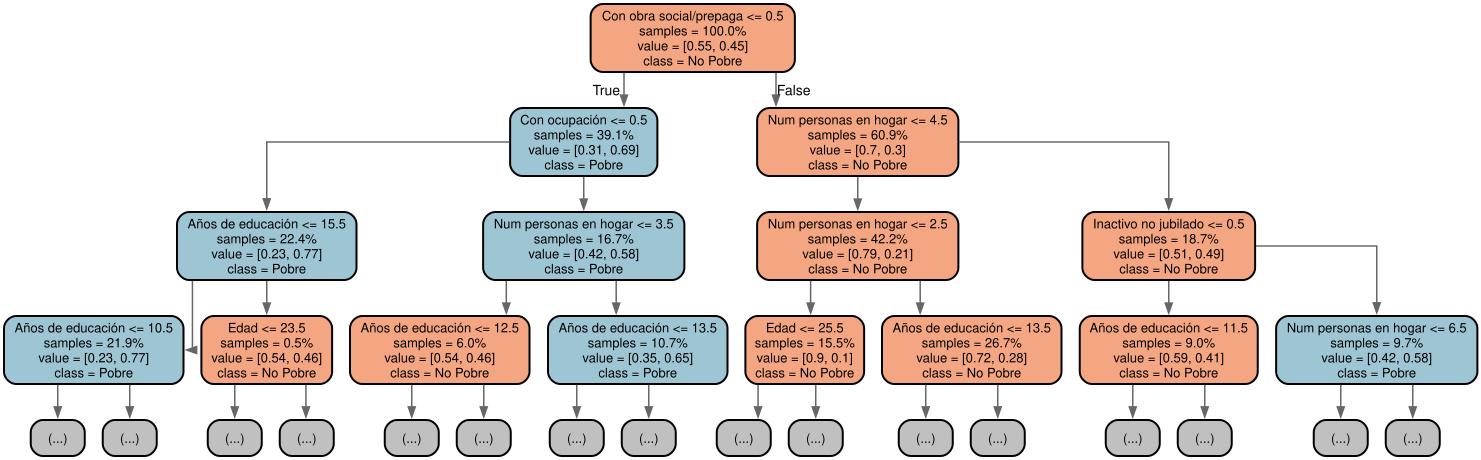

'CART_pobreza_completo.png'

In [43]:
# ================= CONFIGURACIÓN DE ESTILO =================
MAIN_BLUE = "#9ec5d4"      # borde azul suave para pobres
LIGHT_BLUE = "#e8f4f8"     # fondo azul muy claro para pobres
MAIN_ORANGE = "#f4a582"    # borde naranja/salmón suave para no pobres
LIGHT_ORANGE = "#fef3ee"   # fondo naranja/crema muy claro para no pobres
FONT_NAME = "Times New Roman"      
FONT_SIZE = 13
MAX_DEPTH = 3              # Mostrar solo los primeros 3 niveles

# ================= LABELS LINDOS =================
pretty_labels = {
    "con_obra_social_o_prepaga": "Con obra social/prepaga",
    "ocupado": "Con ocupación",
    "IX_TOT": "Num personas en hogar",
    "educ": "Años de educación",
    "log_horastrab": "Horas trabajadas",
    "CH06": "Edad",
    "mujer": "Género (base: mujer)",
    "en_pareja": "En pareja",
    "solo_publica": "Solo salud pública",
    "sin_cobertura": "Sin cobertura",
    "trabajo_no_rem": "Trabajo no remunerado",
    "cuenta_propia_o_patron": "Cuenta propia/Patrón",
    "inactivo_no_jubilado": "Inactivo no jubilado"
}

# -------- FUNCIONES DE AYUDA --------
def sanitize(s):
    """Limpiar caracteres problemáticos para DOT."""
    if not isinstance(s, str):
        s = str(s)
    s = re.sub(r'[\[\]\{\}]', '', s)
    s = s.replace('"', "'")
    return s

# -------- RENOMBRAR FEATURES --------
feat_names = [sanitize(pretty_labels.get(c, c)) for c in X_vars]

# -------- EXPORTAR DOT --------

dot_data = export_graphviz(
    tree_optimal,
    out_file=None,
    feature_names=feat_names,
    class_names=['No Pobre', 'Pobre'],
    filled=True,
    rounded=True,
    max_depth=MAX_DEPTH,
    proportion=True,      # Mostrar proporciones en lugar de conteos
    impurity=False,       # Ocultar gini (menos ruido visual)
    precision=2           # 2 decimales
)

# -------- PERSONALIZAR COLORES POR CLASE --------
# Reemplazar el esquema de colores predeterminado
# Nodos de "Pobre" (class 1) → azul
# Nodos de "No Pobre" (class 0) → naranja

def custom_colors(dot_string):
    """
    Aplicar colores personalizados basados en la clase predicha.
    sklearn colorea según el value, así que necesitamos procesarlo.
    """
    lines = dot_string.split('\n')
    new_lines = []
    
    for line in lines:
        # Detectar nodos (tienen un número seguido de [label=...)
        if 'label=' in line and 'samples' in line:
            # Extraer clase predicha del label
            if 'class = Pobre' in line:
                # Nodo predice "Pobre" → azul
                line = re.sub(r'fillcolor="#[0-9A-Fa-f]{6}"', f'fillcolor="{LIGHT_BLUE}"', line)
                line = re.sub(r'color="#[0-9A-Fa-f]{6}"', f'color="{MAIN_BLUE}"', line)
            elif 'class = No Pobre' in line:
                # Nodo predice "No Pobre" → naranja
                line = re.sub(r'fillcolor="#[0-9A-Fa-f]{6}"', f'fillcolor="{LIGHT_ORANGE}"', line)
                line = re.sub(r'color="#[0-9A-Fa-f]{6}"', f'color="{MAIN_ORANGE}"', line)
        
        new_lines.append(line)
    
    return '\n'.join(new_lines)

dot_data = custom_colors(dot_data)

# -------- MEJORAR ESTILO DE NODOS --------
dot_data = dot_data.replace(
    "shape=box",
    f'shape=box, style="filled,rounded", fontname="{FONT_NAME}", fontsize={FONT_SIZE}, penwidth=2'
)

# Hacer las flechas más elegantes
dot_data = re.sub(r'digraph Tree \{', 
                  'digraph Tree {\nrankdir=TB;\nsplines=ortho;\nedge [penwidth=1.5, color="#666666"];\n', 
                  dot_data)

# -------- RENDERIZAR --------
graph = graphviz.Source(dot_data, format="png")
output_path = graph.render("CART_pobreza_stylized", cleanup=True)

# También mostrar en notebook (si estás en Jupyter)
display(graph) if 'get_ipython' in dir() else None

# -------- VERSIÓN COMPLETA --------

dot_data_full = export_graphviz(
    tree_optimal,
    out_file=None,
    feature_names=feat_names,
    class_names=['No Pobre', 'Pobre'],
    filled=True,
    rounded=True,
    # max_depth=None,  # Sin límite
    proportion=True,
    impurity=False,
    precision=2
)
dot_data_full = custom_colors(dot_data_full)
dot_data_full = dot_data_full.replace("shape=box", 
    f'shape=box, style="filled,rounded", fontname="{FONT_NAME}", fontsize=9, penwidth=2')

graph_full = graphviz.Source(dot_data_full, format="png")
graph_full.render("CART_pobreza_completo", cleanup=True)

### Panel B


 IMPORTANCIA DE VARIABLES:
        Variable_Nombre  Importancia
Con obra social/prepaga     0.477302
  Num personas en hogar     0.221818
      Años de educación     0.079263
                   Edad     0.073247
       Horas trabajadas     0.050268
          Con ocupación     0.042373
   Inactivo no jubilado     0.027315
              En pareja     0.012866
   Género (base: mujer)     0.012462
   Cuenta propia/Patrón     0.003086
     Solo salud pública     0.000000
  Trabajo no remunerado     0.000000


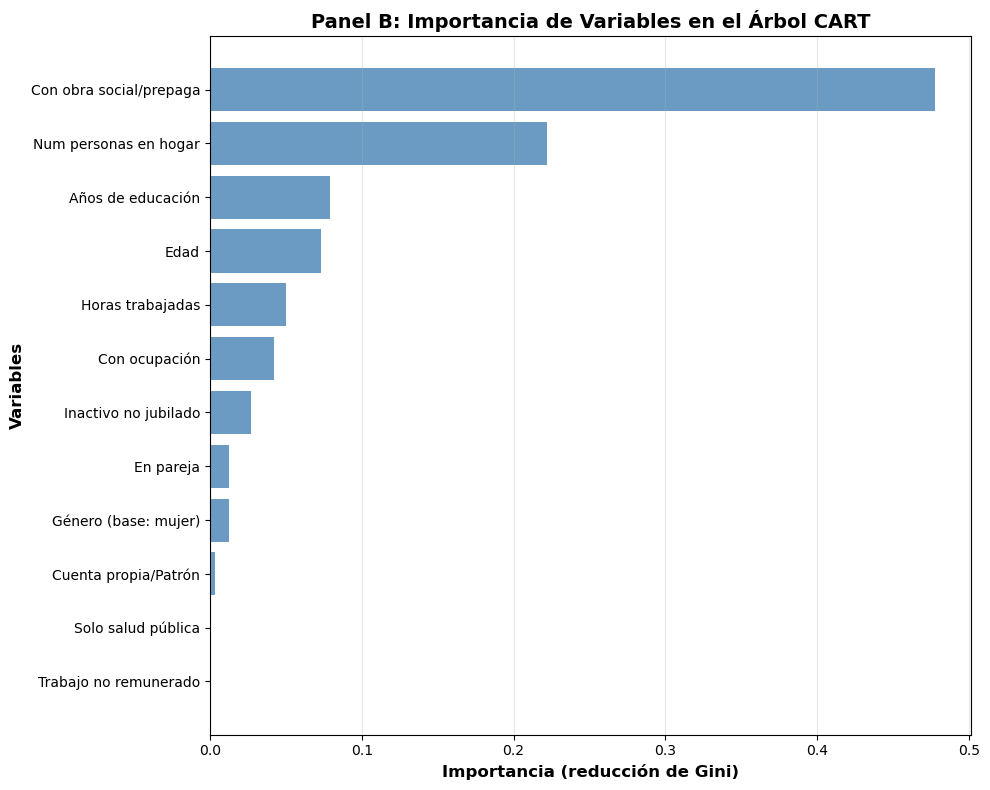

In [29]:
# PANEL B: IMPORTANCIA DE VARIABLES
importances = tree_optimal.feature_importances_
feature_importance_df = pd.DataFrame({
    'Variable': X_vars,
    'Importancia': importances
}).sort_values('Importancia', ascending=False)

# Agregar nombres bonitos
feature_importance_df['Variable_Nombre'] = feature_importance_df['Variable'].map(pretty_labels)

print("\n IMPORTANCIA DE VARIABLES:")
print(feature_importance_df[['Variable_Nombre', 'Importancia']].to_string(index=False))

# Visualización de importancia
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['steelblue' if imp > 0 else 'lightgray' 
         for imp in feature_importance_df['Importancia']]

bars = ax.barh(feature_importance_df['Variable_Nombre'], 
              feature_importance_df['Importancia'],
              color=colors, alpha=0.8)

ax.set_xlabel('Importancia (reducción de Gini)', fontsize=12, fontweight='bold')
ax.set_ylabel('Variables', fontsize=12, fontweight='bold')
ax.set_title('Panel B: Importancia de Variables en el Árbol CART', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('cart_importancia_variables.png', dpi=300, bbox_inches='tight')
plt.show()


# PARTE C: Comparación entre métodos

## Ejercicio 6

In [30]:
# 1. DATOS DEL TP3 (Logit sin penalidad y KNN)

tp3_results = {
    'Logit': {
        'confusion_matrix': np.array([[1101, 357], [440, 698]]),
        'accuracy': 0.692989,
        'precision': 0.661611,
        'recall': 0.613357,
        'f1_score': 0.636571,
        'auc': 0.764837
    },
    'KNN (k=16)': {
        'confusion_matrix': np.array([[1168, 290], [390, 748]]),
        'accuracy': 0.738059,
        'precision': 0.720617,
        'recall': 0.657293,
        'f1_score': 0.687500,
        'auc': 0.815265
    }
}


In [31]:
# 2. ENTRENAR Y EVALUAR MODELOS NUEVOS

# Verificar que tenemos X_train_scaled (numpy array)
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled_array = X_train_scaled.values
else:
    X_train_scaled_array = X_train_scaled

if isinstance(X_test_scaled, pd.DataFrame):
    X_test_scaled_array = X_test_scaled.values
else:
    X_test_scaled_array = X_test_scaled

y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test

### RIDGE

In [32]:
# 2A. LOGIT CON RIDGE (L2)

ridge_best_C = 1.0  # Del Punto 2
model_ridge = LogisticRegression(penalty='l2', C=ridge_best_C, 
                                 solver='lbfgs', max_iter=1000, random_state=444)
model_ridge.fit(X_train_scaled_array, y_train_array)

# Predicciones
y_pred_ridge = model_ridge.predict(X_test_scaled_array)
y_proba_ridge = model_ridge.predict_proba(X_test_scaled_array)[:, 1]

# Métricas
cm_ridge = confusion_matrix(y_test_array, y_pred_ridge)
acc_ridge = accuracy_score(y_test_array, y_pred_ridge)
prec_ridge = precision_score(y_test_array, y_pred_ridge)
rec_ridge = recall_score(y_test_array, y_pred_ridge)
f1_ridge = f1_score(y_test_array, y_pred_ridge)
auc_ridge = roc_auc_score(y_test_array, y_proba_ridge)

print(f"   Accuracy: {acc_ridge:.4f}, AUC: {auc_ridge:.4f}")

   Accuracy: 0.6930, AUC: 0.7649


### LASSO

In [33]:
# 2B. LOGIT CON LASSO (L1)

lasso_best_C = 1.0  # Del Punto 2
model_lasso = LogisticRegression(penalty='l1', C=lasso_best_C, 
                                 solver='liblinear', max_iter=1000, random_state=444)
model_lasso.fit(X_train_scaled_array, y_train_array)

# Predicciones
y_pred_lasso = model_lasso.predict(X_test_scaled_array)
y_proba_lasso = model_lasso.predict_proba(X_test_scaled_array)[:, 1]

# Métricas
cm_lasso = confusion_matrix(y_test_array, y_pred_lasso)
acc_lasso = accuracy_score(y_test_array, y_pred_lasso)
prec_lasso = precision_score(y_test_array, y_pred_lasso)
rec_lasso = recall_score(y_test_array, y_pred_lasso)
f1_lasso = f1_score(y_test_array, y_pred_lasso)
auc_lasso = roc_auc_score(y_test_array, y_proba_lasso)

print(f"   Accuracy: {acc_lasso:.4f}, AUC: {auc_lasso:.4f}")

   Accuracy: 0.6934, AUC: 0.7649


### CART

In [34]:
# 2C. ÁRBOL DE DECISIÓN (CART)

# Usar datos sin escalar para el árbol (no necesita estandarización)
best_ccp_alpha = best_ccp_alpha  # Del Punto 4
tree_optimal = DecisionTreeClassifier(ccp_alpha=best_ccp_alpha, random_state=444)
tree_optimal.fit(X_train, y_train)

# Predicciones
y_pred_tree = tree_optimal.predict(X_test)
y_proba_tree = tree_optimal.predict_proba(X_test)[:, 1]

# Métricas
cm_tree = confusion_matrix(y_test, y_pred_tree)
acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_proba_tree)

print(f"   Accuracy: {acc_tree:.4f}, AUC: {auc_tree:.4f}")

   Accuracy: 0.7053, AUC: 0.7515


### Métricas de comparación

In [35]:
# 3. TABLA COMPARATIVA COMPLETA

print("\n" + "="*70)
print("TABLA COMPARATIVA - TODOS LOS MODELOS")
print("="*70)

# Crear DataFrame con todos los resultados
resultados = pd.DataFrame({
    'Modelo': ['Logit (sin penalidad)', 'KNN (k=16)', 'Logit + Ridge (L2)', 
               'Logit + LASSO (L1)', 'Árbol CART'],
    'Accuracy': [
        tp3_results['Logit']['accuracy'],
        tp3_results['KNN (k=16)']['accuracy'],
        acc_ridge,
        acc_lasso,
        acc_tree
    ],
    'Precision': [
        tp3_results['Logit']['precision'],
        tp3_results['KNN (k=16)']['precision'],
        prec_ridge,
        prec_lasso,
        prec_tree
    ],
    'Recall': [
        tp3_results['Logit']['recall'],
        tp3_results['KNN (k=16)']['recall'],
        rec_ridge,
        rec_lasso,
        rec_tree
    ],
    'F1-Score': [
        tp3_results['Logit']['f1_score'],
        tp3_results['KNN (k=16)']['f1_score'],
        f1_ridge,
        f1_lasso,
        f1_tree
    ],
    'AUC': [
        tp3_results['Logit']['auc'],
        tp3_results['KNN (k=16)']['auc'],
        auc_ridge,
        auc_lasso,
        auc_tree
    ],
    '1-Accuracy (Error)': [
        1 - tp3_results['Logit']['accuracy'],
        1 - tp3_results['KNN (k=16)']['accuracy'],
        1 - acc_ridge,
        1 - acc_lasso,
        1 - acc_tree
    ]
})

# Ordenar por AUC (mejor primero)
resultados = resultados.sort_values('AUC', ascending=False).reset_index(drop=True)

print("\n" + resultados.to_string(index=False))


TABLA COMPARATIVA - TODOS LOS MODELOS

               Modelo  Accuracy  Precision   Recall  F1-Score      AUC  1-Accuracy (Error)
           KNN (k=16)  0.738059   0.720617 0.657293  0.687500 0.815265            0.261941
   Logit + LASSO (L1)  0.693374   0.662239 0.613357  0.636861 0.764894            0.306626
   Logit + Ridge (L2)  0.692989   0.661611 0.613357  0.636571 0.764858            0.307011
Logit (sin penalidad)  0.692989   0.661611 0.613357  0.636571 0.764837            0.307011
           Árbol CART  0.705316   0.663740 0.664323  0.664032 0.751526            0.294684


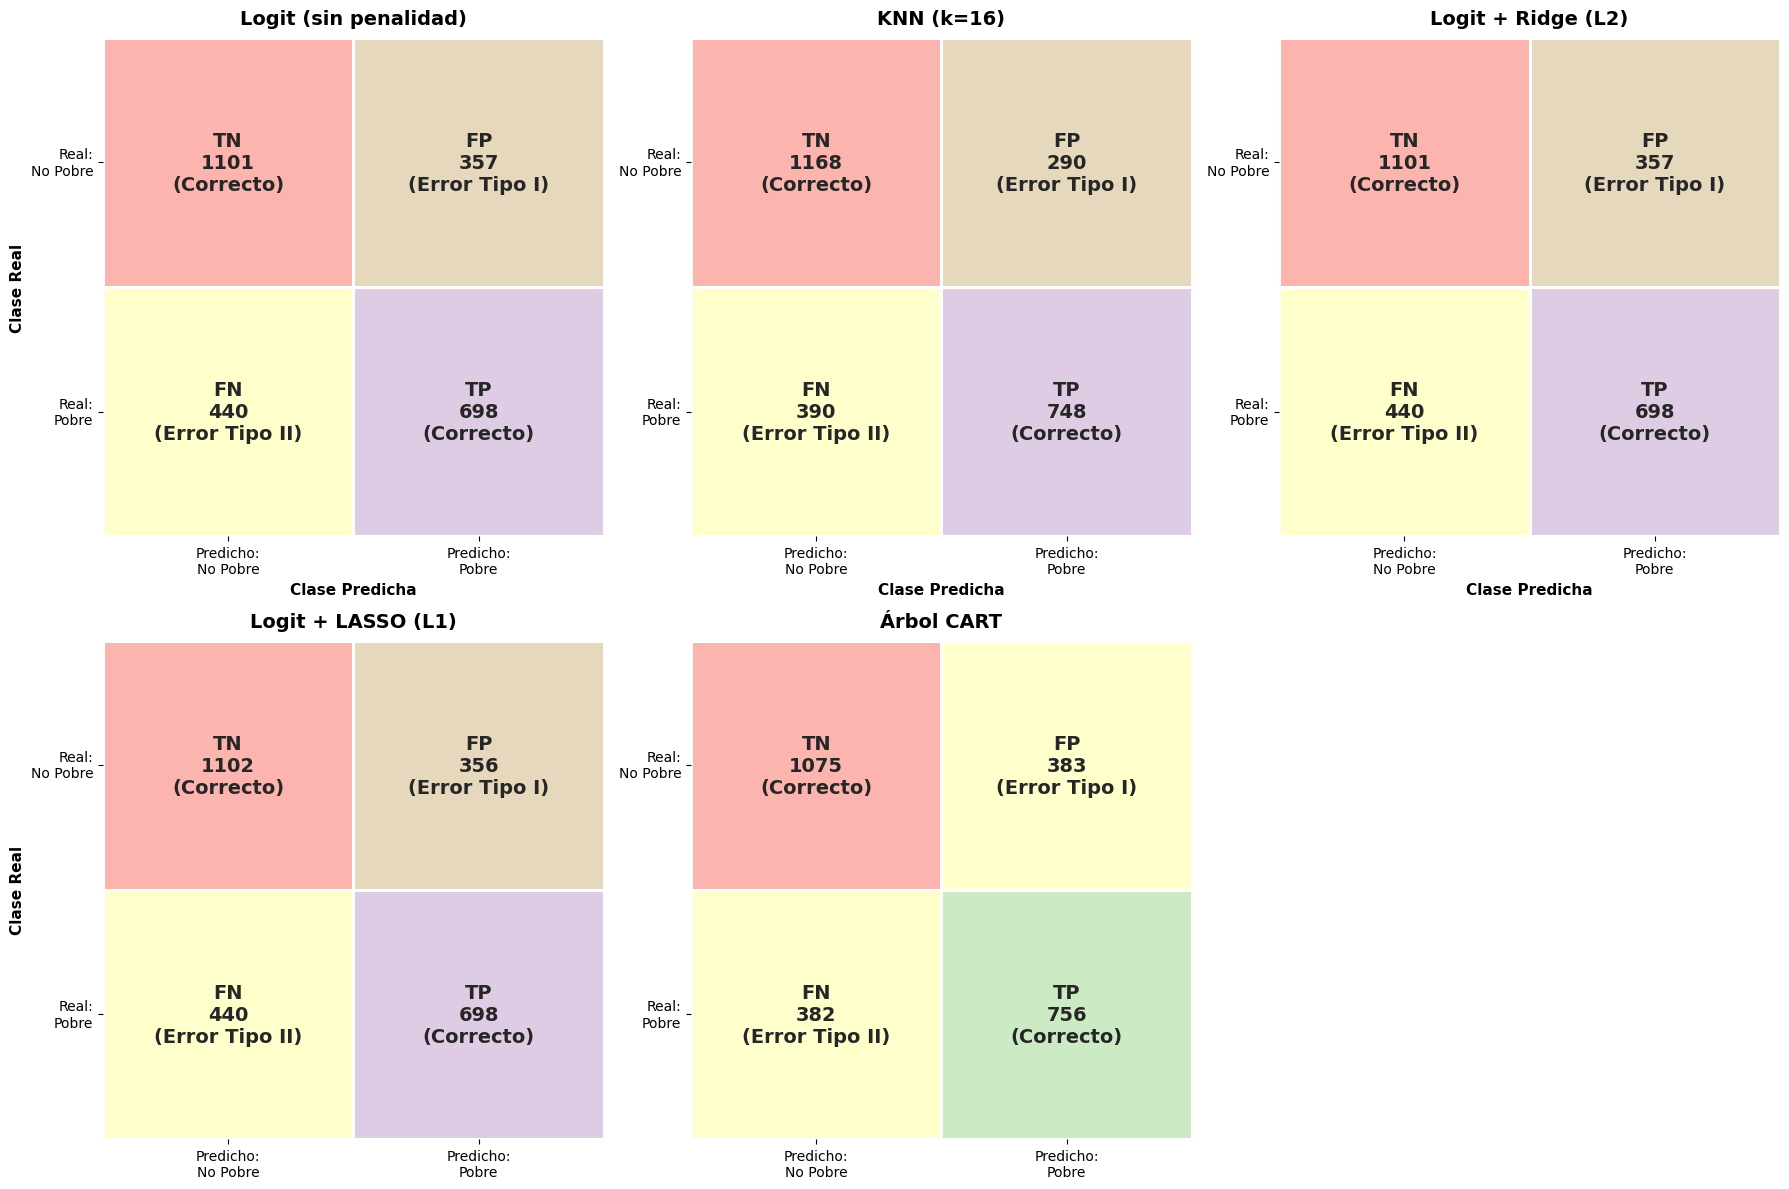

In [36]:
# 4. VISUALIZACIÓN: MATRICES DE CONFUSIÓN

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

matrices = [
    (tp3_results['Logit']['confusion_matrix'], 'Logit (sin penalidad)'),
    (tp3_results['KNN (k=16)']['confusion_matrix'], 'KNN (k=16)'),
    (cm_ridge, 'Logit + Ridge (L2)'),
    (cm_lasso, 'Logit + LASSO (L1)'),
    (cm_tree, 'Árbol CART')
]

for i, (cm, nombre) in enumerate(matrices):
    # Crear anotaciones personalizadas con etiquetas
    tn, fp, fn, tp = cm.ravel()
    
    # Texto personalizado para cada celda
    annotations = np.array([
        [f'TN\n{tn}\n(Correcto)', f'FP\n{fp}\n(Error Tipo I)'],
        [f'FN\n{fn}\n(Error Tipo II)', f'TP\n{tp}\n(Correcto)']
    ])
    
    # Heatmap con colores pasteles
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Pastel1_r', 
                xticklabels=['Predicho:\nNo Pobre', 'Predicho:\nPobre'],
                yticklabels=['Real:\nNo Pobre', 'Real:\nPobre'],
                ax=axes[i], cbar=False, 
                linewidths=2, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'},  # Letra más grande
                vmin=0, vmax=cm.max())
    
    # Título sin métricas
    axes[i].set_title(nombre, fontsize=14, fontweight='bold', pad=10)
    
    # Etiquetas de ejes (condicionales)
    # Clase Real:
    if i in [0, 3]:
        axes[i].set_ylabel('Clase Real', fontsize=11, fontweight='bold')
    else:
        axes[i].set_ylabel('')
    
    # Clase Predicha:
    if i in [0,1,2]:
        axes[i].set_xlabel('Clase Predicha', fontsize=11, fontweight='bold')
    else:
        axes[i].set_xlabel('')
    
    # Rotar etiquetas para mejor lectura
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].tick_params(axis='y', rotation=0)

# Ocultar último subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('matrices_confusion_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

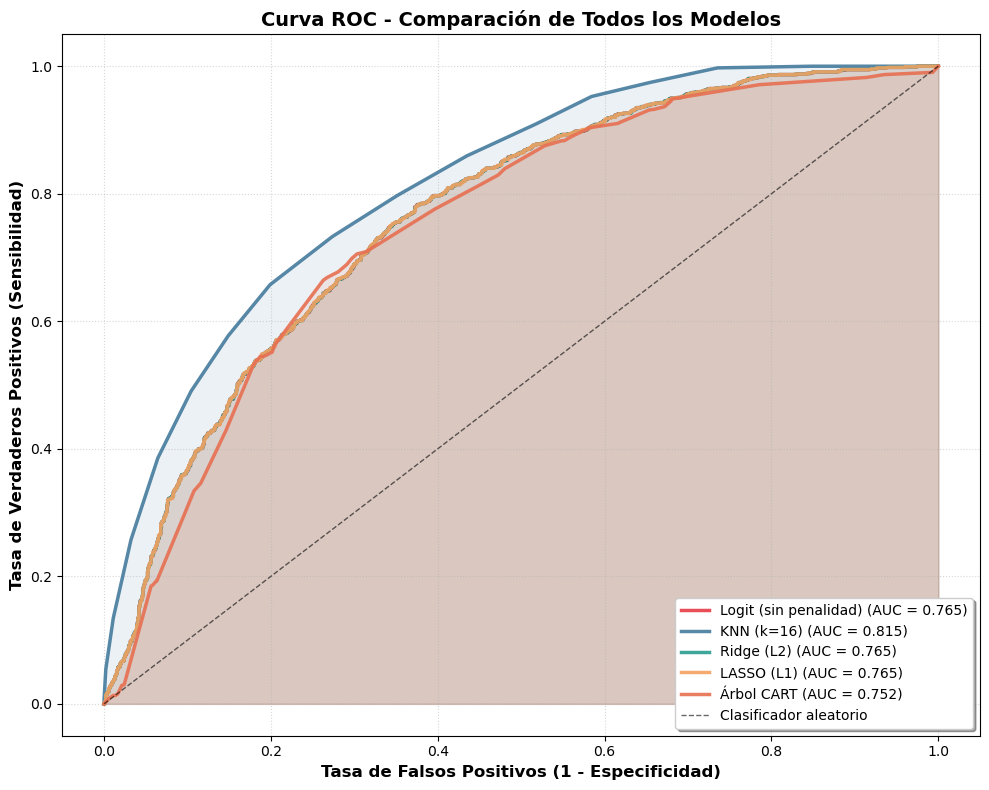

In [37]:
# 5. VISUALIZACIÓN: CURVAS ROC
fig, ax = plt.subplots(figsize=(10, 8))

# Intentar cargar probabilidades del TP3
try:
    y_pred_prob_logit = np.load('y_pred_prob_logit.npy')
    y_pred_prob_knn = np.load('y_pred_prob_knn.npy')
    tiene_probs_tp3 = True
except:
    tiene_probs_tp3 = False
    print("  No se encontraron probabilidades del TP3")

# Paleta de colores
colors = {
    'logit': '#E63946',
    'knn': '#457B9D', 
    'ridge': '#2A9D8F',
    'lasso': '#F4A261',
    'tree': '#E76F51'
}

# Logit del TP3
if tiene_probs_tp3:
    fpr_logit_tp3, tpr_logit_tp3, _ = roc_curve(y_test_array, y_pred_prob_logit)
    ax.plot(fpr_logit_tp3, tpr_logit_tp3, color=colors['logit'], linewidth=2.5,
            label=f'Logit (sin penalidad) (AUC = {tp3_results["Logit"]["auc"]:.3f})', alpha=0.9)
    ax.fill_between(fpr_logit_tp3, tpr_logit_tp3, alpha=0.1, color=colors['logit'])

# KNN del TP3
if tiene_probs_tp3:
    fpr_knn_tp3, tpr_knn_tp3, _ = roc_curve(y_test_array, y_pred_prob_knn)
    ax.plot(fpr_knn_tp3, tpr_knn_tp3, color=colors['knn'], linewidth=2.5,
            label=f'KNN (k=16) (AUC = {tp3_results["KNN (k=16)"]["auc"]:.3f})', alpha=0.9)
    ax.fill_between(fpr_knn_tp3, tpr_knn_tp3, alpha=0.1, color=colors['knn'])

# Ridge
fpr_ridge, tpr_ridge, _ = roc_curve(y_test_array, y_proba_ridge)
ax.plot(fpr_ridge, tpr_ridge, color=colors['ridge'], linewidth=2.5,
        label=f'Ridge (L2) (AUC = {auc_ridge:.3f})', alpha=0.9)
ax.fill_between(fpr_ridge, tpr_ridge, alpha=0.1, color=colors['ridge'])

# LASSO
fpr_lasso, tpr_lasso, _ = roc_curve(y_test_array, y_proba_lasso)
ax.plot(fpr_lasso, tpr_lasso, color=colors['lasso'], linewidth=2.5,
        label=f'LASSO (L1) (AUC = {auc_lasso:.3f})', alpha=0.9)
ax.fill_between(fpr_lasso, tpr_lasso, alpha=0.1, color=colors['lasso'])

# CART
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
ax.plot(fpr_tree, tpr_tree, color=colors['tree'], linewidth=2.5,
        label=f'Árbol CART (AUC = {auc_tree:.3f})', alpha=0.9)
ax.fill_between(fpr_tree, tpr_tree, alpha=0.1, color=colors['tree'])

# Línea diagonal (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Clasificador aleatorio')

# Si no se cargaron las probs del TP3, agregar sus AUC en la leyenda
if not tiene_probs_tp3:
    ax.plot([], [], ' ', label=f'[Logit TP3: AUC = {tp3_results["Logit"]["auc"]:.3f}]')
    ax.plot([], [], ' ', label=f'[KNN TP3: AUC = {tp3_results["KNN (k=16)"]["auc"]:.3f}]')

ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', 
             fontsize=12, fontweight='bold')
ax.set_title('Curva ROC - Comparación de Todos los Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('curvas_roc_comparacion_completa.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# 6. ANÁLISIS DETALLADO POR MÉTRICA

print("\n" + "="*70)
print("ANÁLISIS POR MÉTRICA")
print("="*70)

print("\n🏆 RANKING POR ACCURACY:")
for i, row in resultados.sort_values('Accuracy', ascending=False).iterrows():
    print(f"   {i+1}. {row['Modelo']}: {row['Accuracy']:.4f}")

print("\n🏆 RANKING POR AUC:")
for i, row in resultados.sort_values('AUC', ascending=False).iterrows():
    print(f"   {i+1}. {row['Modelo']}: {row['AUC']:.4f}")

print("\n🏆 RANKING POR RECALL (Sensibilidad - detectar pobres):")
for i, row in resultados.sort_values('Recall', ascending=False).iterrows():
    print(f"   {i+1}. {row['Modelo']}: {row['Recall']:.4f}")

print("\n🏆 RANKING POR F1-SCORE (balance):")
for i, row in resultados.sort_values('F1-Score', ascending=False).iterrows():
    print(f"   {i+1}. {row['Modelo']}: {row['F1-Score']:.4f}")


ANÁLISIS POR MÉTRICA

🏆 RANKING POR ACCURACY:
   1. KNN (k=16): 0.7381
   5. Árbol CART: 0.7053
   2. Logit + LASSO (L1): 0.6934
   3. Logit + Ridge (L2): 0.6930
   4. Logit (sin penalidad): 0.6930

🏆 RANKING POR AUC:
   1. KNN (k=16): 0.8153
   2. Logit + LASSO (L1): 0.7649
   3. Logit + Ridge (L2): 0.7649
   4. Logit (sin penalidad): 0.7648
   5. Árbol CART: 0.7515

🏆 RANKING POR RECALL (Sensibilidad - detectar pobres):
   5. Árbol CART: 0.6643
   1. KNN (k=16): 0.6573
   4. Logit (sin penalidad): 0.6134
   3. Logit + Ridge (L2): 0.6134
   2. Logit + LASSO (L1): 0.6134

🏆 RANKING POR F1-SCORE (balance):
   1. KNN (k=16): 0.6875
   5. Árbol CART: 0.6640
   2. Logit + LASSO (L1): 0.6369
   4. Logit (sin penalidad): 0.6366
   3. Logit + Ridge (L2): 0.6366
